In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

d:\A\LangGraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
# initialize groq model 
llm = ChatGroq(
    model ="llama-3.3-70b-versatile",
    temperature=0
)

In [5]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_bangla: str

In [13]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Bangla.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = llm.invoke(prompt).content

    return {'answer_bangla': translated_text}

In [14]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [15]:
def generate_answer(state: ParentState):

    answer = llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [16]:

parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

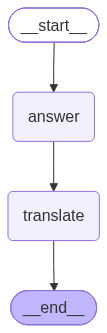

In [17]:
graph = parent_builder.compile()

graph

In [18]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum Physics: A Brief Overview**\n\nQuantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at an atomic and subatomic level. It explores the properties and interactions of particles that are too small to be seen with the naked eye, such as atoms, electrons, and photons.\n\n**Key Principles:**\n\n1. **Wave-Particle Duality**: Quantum objects can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quantum objects can become "entangled" in a way that the state of one object is dependent on the state of the other, ev